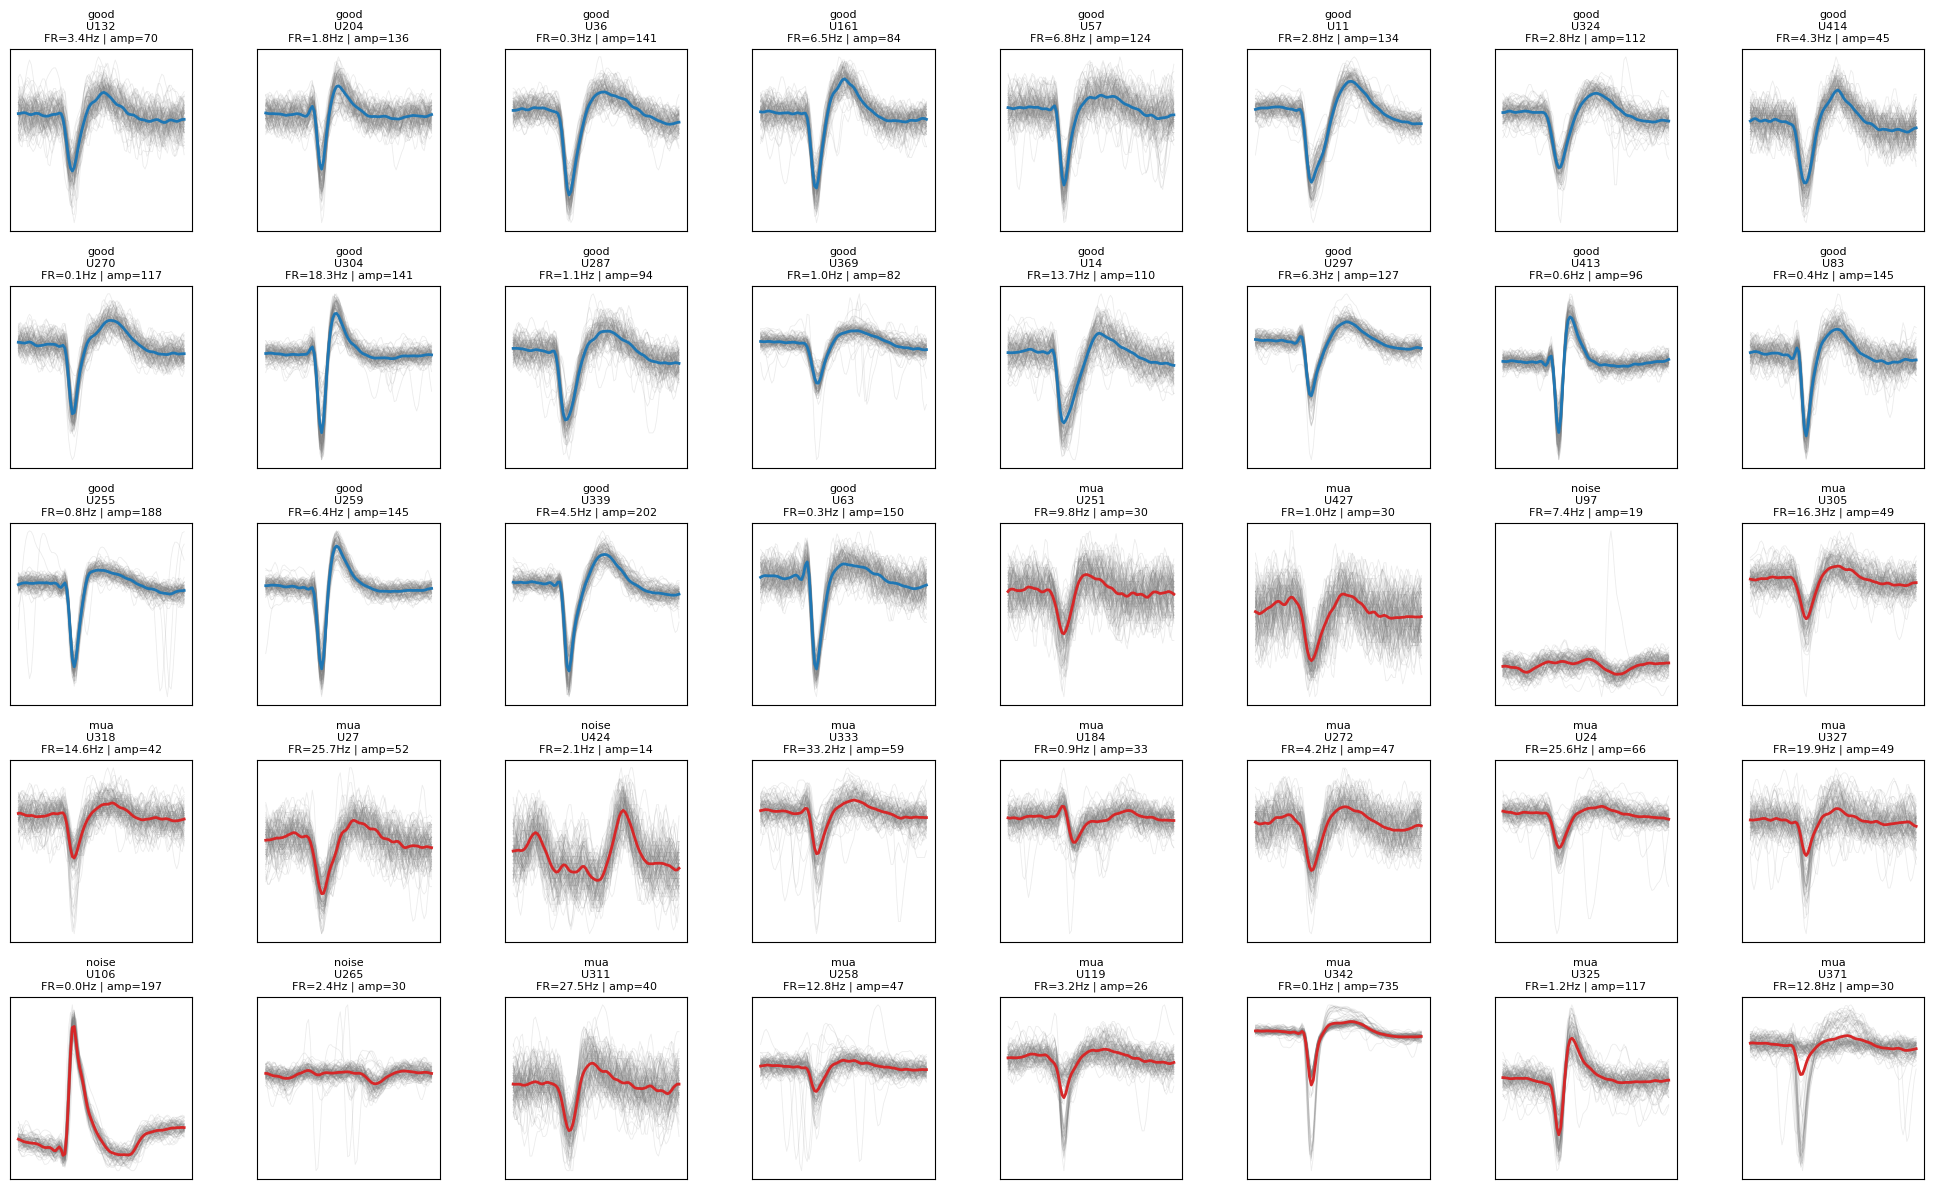

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import spikeinterface.full as si

# === PATHS ===
analyzer_path = r"F:\Data_Mice_IBL\VF074v3\2026_03_24\sorting_analyzer\probe00"
bombcell_csv = r"F:\Data_Mice_IBL\VF074v3\2026_03_24\bombcell\probe00\bombcell_labels.csv"

# === LOAD ===
analyzer = si.load_sorting_analyzer(analyzer_path)
sorting = analyzer.sorting
labels = pd.read_csv(bombcell_csv, index_col=0)

# === UNITS ===
good_units = labels.loc[labels["bombcell_label"] == "good"].index.astype(int).to_numpy()
bad_units = labels.loc[labels["bombcell_label"].isin(["noise", "mua"])].index.astype(int).to_numpy()

np.random.seed(0)
good_to_show = np.random.choice(good_units, size=min(20, len(good_units)), replace=False)
bad_to_show = np.random.choice(bad_units, size=min(20, len(bad_units)), replace=False)

units_to_show = np.concatenate([good_to_show, bad_to_show])

# === EXTENSIONS ===
waveforms_ext = analyzer.get_extension("waveforms")
amp_ext = analyzer.get_extension("spike_amplitudes")

amplitudes = amp_ext.get_data()

spike_vector = sorting.to_spike_vector()
unit_ids_all = np.array(sorting.unit_ids)
spike_unit_ids = unit_ids_all[spike_vector["unit_index"]]
times = spike_vector["sample_index"] / analyzer.sampling_frequency

fs = analyzer.sampling_frequency
duration_s = times.max()

# === PLOT ===
n_cols = 8
n_rows = int(np.ceil(len(units_to_show) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 12))
axes = axes.flatten()

for ax, unit_id in zip(axes, units_to_show):
    waveforms = waveforms_ext.get_waveforms_one_unit(unit_id)

    spike_train = sorting.get_unit_spike_train(unit_id)
    n_spikes_total = len(spike_train)

    firing_rate = n_spikes_total / duration_s if duration_s > 0 else np.nan

    n_show = min(100, waveforms.shape[0])
    wf_all = waveforms[:n_show]

    mean_wf = wf_all.mean(axis=0)
    best_chan = np.argmax(np.max(np.abs(mean_wf), axis=0))
    wf = wf_all[:, :, best_chan]

    t_ms = np.arange(wf.shape[1]) / fs * 1000

    unit_mask = spike_unit_ids == unit_id
    amp_unit = amplitudes[unit_mask]
    amp_median = np.median(np.abs(amp_unit)) if amp_unit.size > 0 else np.nan

    label = labels.loc[unit_id, "bombcell_label"]
    color = "tab:blue" if label == "good" else "tab:red"

    for i in range(n_show):
        ax.plot(t_ms, wf[i], alpha=0.15, linewidth=0.6, color="gray")

    ax.plot(t_ms, wf.mean(axis=0), linewidth=2, color=color)

    ax.set_title(
        f"{label}\nU{unit_id}\nFR={firing_rate:.1f}Hz | amp={amp_median:.0f}",
        fontsize=8
    )

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_box_aspect(1)

for i in range(len(units_to_show), len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()